
## Demo


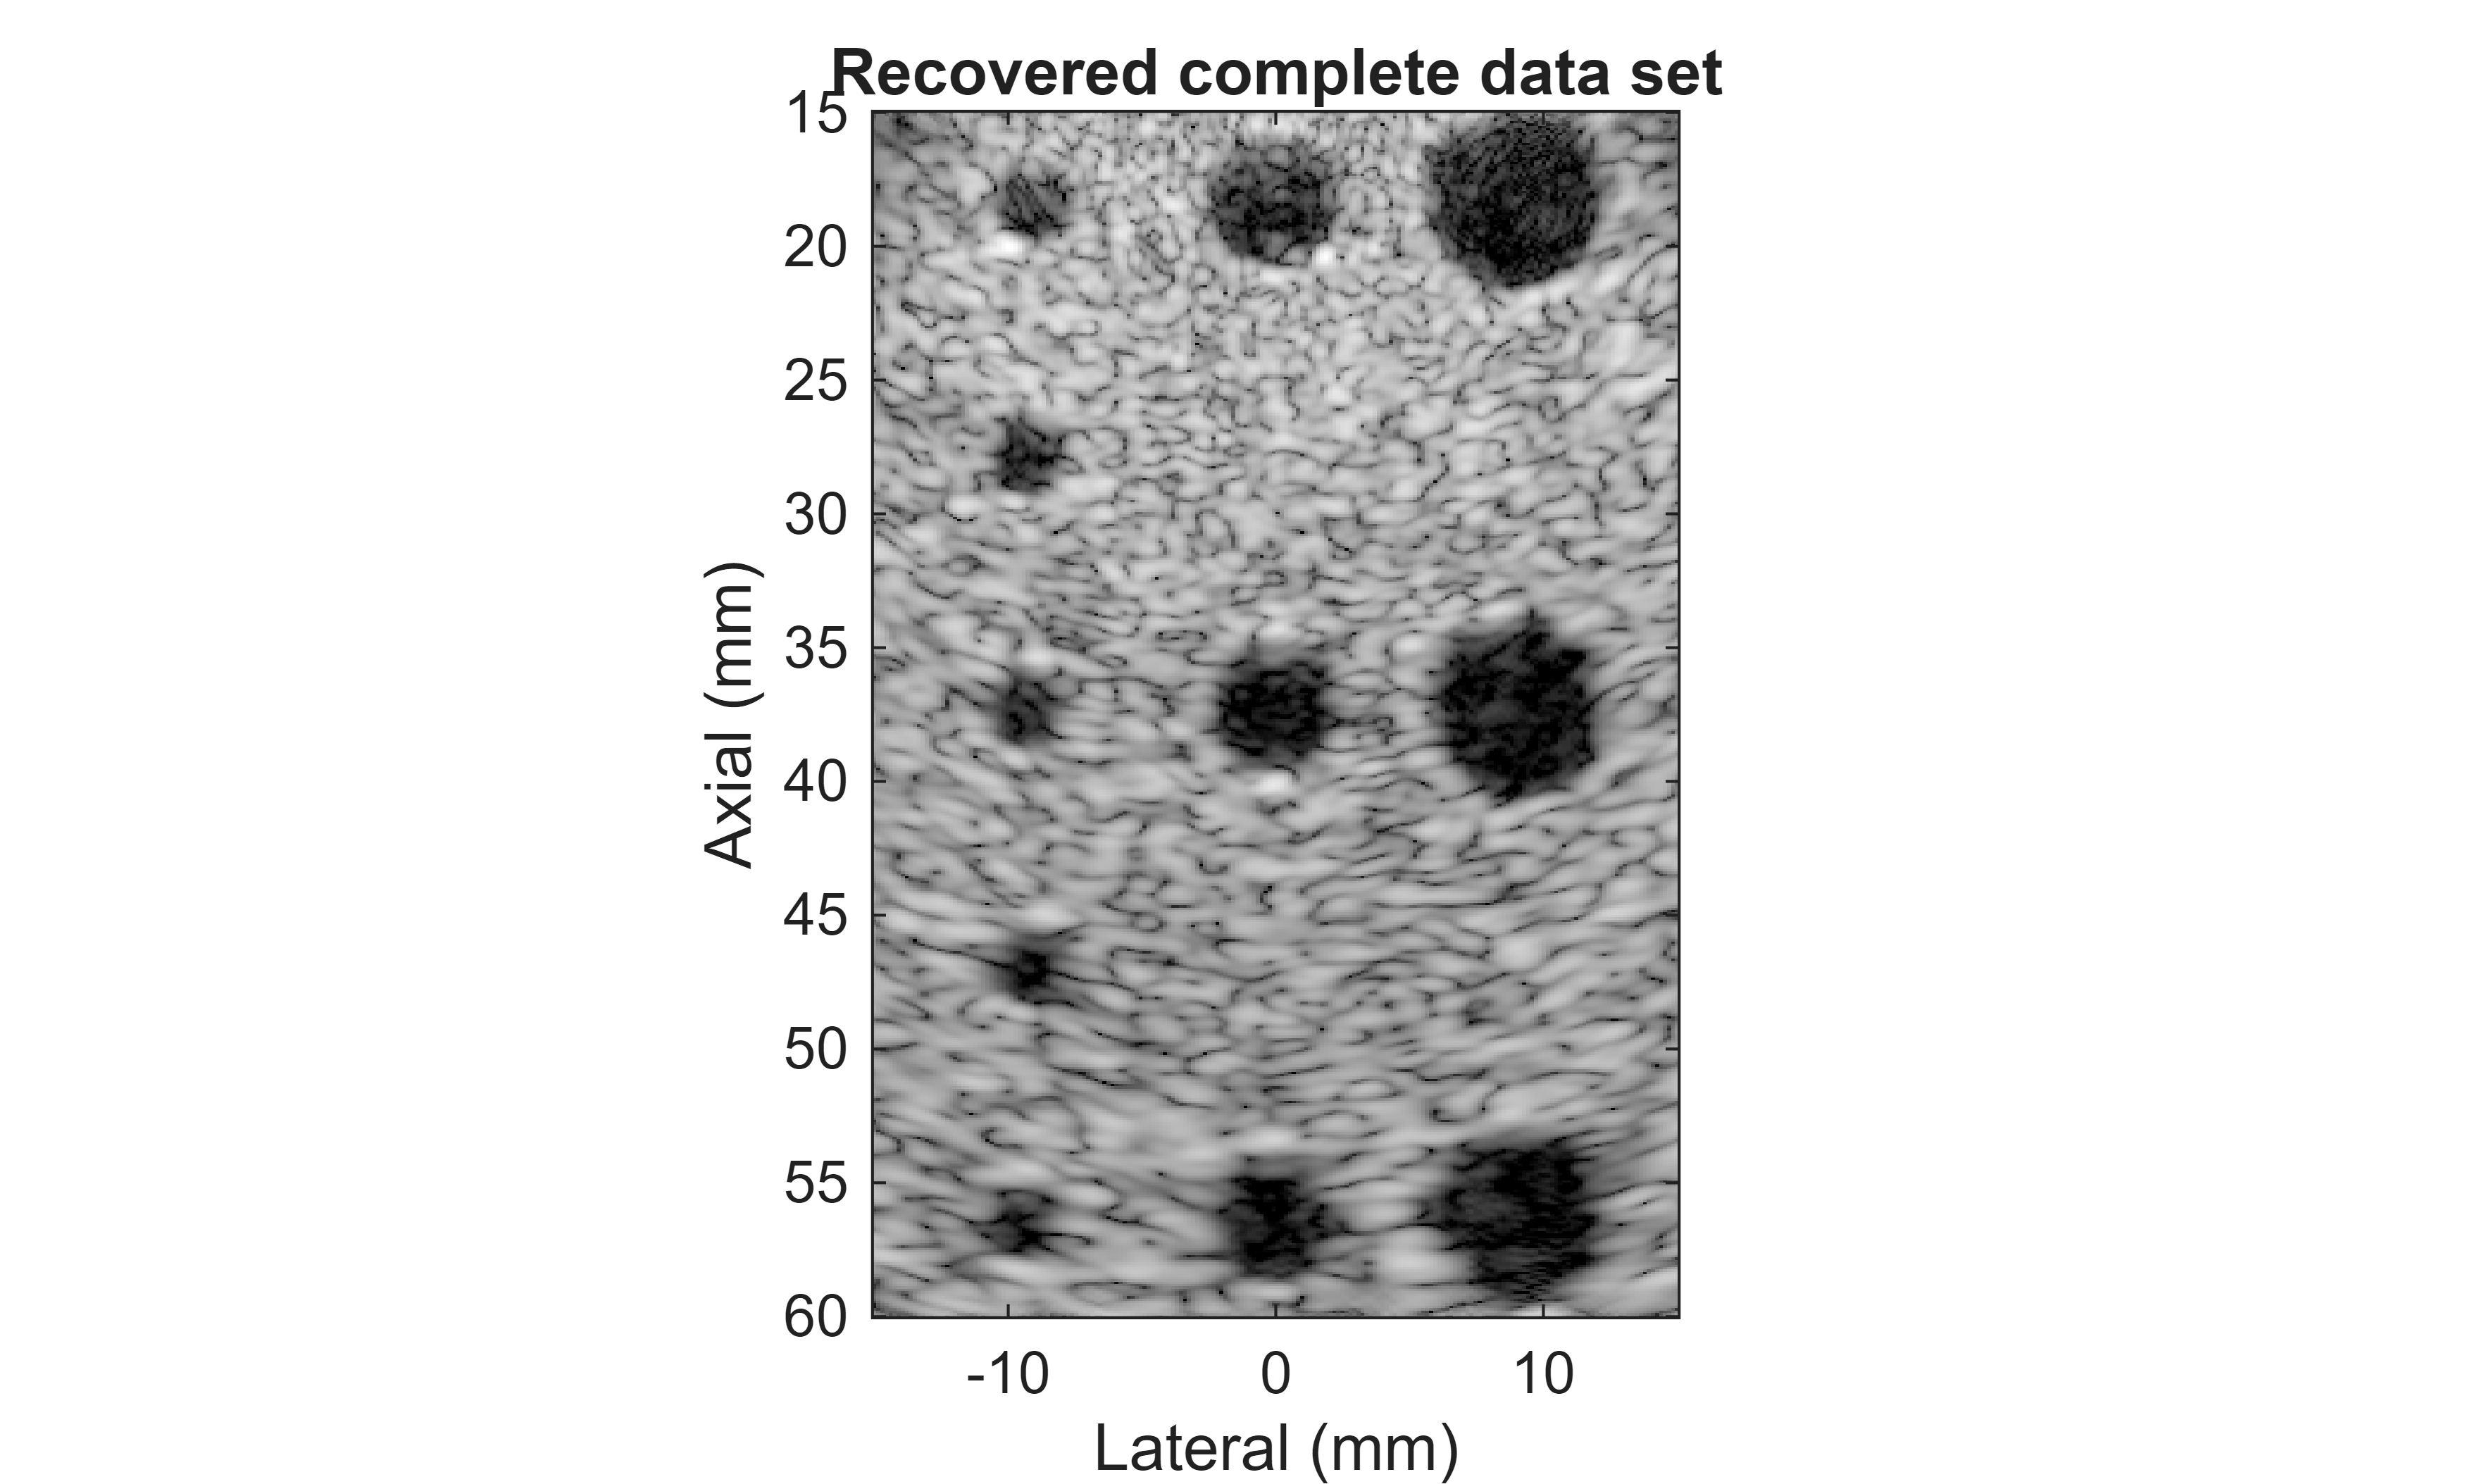

In [1]:
% Load the sample data and transmit delay timings
load('sample_data.mat');

% Optionally reduce the number of transmit events in the saved data
% ds=6;
% rf=rf(:,:,1:ds:end);
% transmit_delays=transmit_delays(1:ds:end,:);

% Perform decoding to produce the complete data set
rf_fsa=decode_focused_beams(rf,transmit_delays);

% Perform a basic diverging wave focusing of the complete data set
x=linspace(-15,15,200)/1000; % [m]
z=linspace(15,60,500)/1000; % [m]
r=(params.t0+(0:size(rf_fsa,1)-1))/params.fs*params.c; % [m] = c . tn
rf_focused=beamform(rf_fsa,r,params.rx_pos,x,z);

% Apply a high-pass filter to the data to remove interpolation artifacts
[b,a]=butter(2,500e3/(params.fs/2),'high');
rf_focused=filter(b,a,rf_focused);

% Display image
env=abs(hilbert(rf_focused));
env=env/max(env(:));
imagesc(x*1e3,z*1e3,db(env),[-50 0]);axis image;colormap gray
xlabel('Lateral (mm)')
ylabel('Axial (mm)')
title('Recovered complete data set')

In [2]:

% Load the saved figures
% openfig('dynamic_receive.fig')
% openfig('recovered_complete.fig')

% s**-1 / m*s^-1

## Decode

# <span style="color:rgb(213,80,0)">Intuition in plain words</span>

This function says:

-  “I know those delays.”
-  “So I can undo the coding caused by those delays.”
-  “After undoing them, I can reorganize the data as if I had access to transmit\-element\-resolved data.”

The interpolation in the time version is simply the mechanism used to apply **fractional sample shifts**.


In [3]:
function [rf_fsa] = decode_focused_beams(rf,transmit_delays,method)
%DECODE_FOCUSED_BEAMS - Decode RF channel data from a set of focused
% transmit beams into the complete data set using the applied focal timings
%
% rf_fsa = decode_focused_beams(rf,transmit_delays);
% rf_fsa = decode_focused_beams(rf,transmit_delays, METHOD);
%
% Decoding can be performed in either the time or frequency domains. The
% two methods produce the same result, but frequency is faster.
%
% Parameters:
% rf - RF data (time sample x receive channel x transmit event)
% transmit_delays - Transmit focal delays in samples (transmit event x transmit element)
% method - 'frequency' or 'time' (default: frequency)
%
% Returns:
% rf_fsa - Decoded complete data set (time sample x receive channel x transmit element)
%
% Author: Nick Bottenus
% Contact: nick.bottenus@duke.edu

% Check inputs
if(~exist('method','var'))
    method='frequency';
else
    assert(strcmp(method,'frequency')||strcmp(method,'time'),'Method must be ''frequency'' or ''time''')
end
[n_samples, n_receives, n_transmits]=size(rf);
n_elements=size(transmit_delays,2);
assert(size(transmit_delays,1)==n_transmits,'Transmit event dimensions inconsistent between rf and transmit_timings')

switch method

    % ======================================Frequency domain implementation
    case 'frequency'

    % 1-D FFT to convert time to frequency
    RF=fft(single(rf));
    RF=permute(RF,[2 3 1]); % (receive channel x transmit event x time sample)
    frequency=(0:n_samples-1)/n_samples;

    % Apply decoding matrix at each frequency
    RF_adj=zeros(n_samples,n_receives,n_elements,'single');
    for i=1:ceil(n_samples/2) % only compute half, assume symmetry
        omega=2*pi*frequency(i);
        Hinv=exp(1j*omega*transmit_delays);
        RF_adj(i,:,:)=RF(:,:,i)*Hinv;
    end

    % Inverse FFT for real signal
    rf_fsa=ifft(RF_adj,'symmetric');

    % ===========================================Time domain implementation
    case 'time'

    rf_fsa=zeros(n_samples,n_receives,n_elements,'single');
    samples=1:n_samples;
    % Interpolate the data for each transmit event with delays
    % corresponding to each recovered transmit element
    for j=1:n_transmits
        rf_fsa=rf_fsa+interp1(samples,single(rf(:,:,j)),...
            repmat(samples(:),1,n_elements)+repmat(transmit_delays(j,:),n_samples,1),...
            'linear');
    end
    rf_fsa(isnan(rf_fsa))=0;
end
end

## **Frequency\-domain method**: apply phase factors

$$Y\left(r,m,\omega \;\right)=\sum_{j=1}^{N_{\textrm{tx}} } X\left(r,j,\omega \right)e^{j\omega \;\tau_{j\ldotp m} }$$

-  $X\left(r,j,\omega \right)$ is the RF from transmit event j
-  $\;\tau_{j\ldotp m}$ is the delay applied to element $m$ during event $j$

Then inverse FFT gives $y\left(r\ldotp m,n\right)$

-
-  **Time\-domain method**: shift/interpolate signals directly in time
## **Time\-domain method**: shift/interpolate signals directly in time

$$q=k+a,0\le a<1$$

then, $x\left(q\right)\approx \left(1-\alpha \;\right)x\left(k\right)+\alpha \;x\left(k+1\right)$


 `rf_fs(:,r,m) += interp( rf(:,r,j),` *`samples`* `+` $\tau_{j\ldotp m}$ )


Each focused transmission is a coded combination of element emissions. So to recover element\-based data, you combine information from all transmit events.

## Beamforming

# <span style="color:rgb(213,80,0)">Intuition in plain words</span>

This code says:

-  “For each image pixel, I know how far it is from every element.”
-  “For each transmit\-receive element pair, I know the total travel distance from TX to pixel to RX.”
-  “So I read the RF trace at that distance.”
-  “Then I sum all pair contributions.”
-  “The places where many pairs agree become bright.”

That is beamforming.

###  `function [rf_focused] = beamform(rf_fsa,r,rx_pos,x,z)`
-  `rf_fsa`: RF data indexed as**(range/time sample, receive element, transmit element)**
-  `r`: the depth/range axis corresponding to the first dimension of `rf_fsa`
-  `rx_pos`: positions of the array elements, probably one row per element, with coordinates like `[x y z]`
-  `x`, `z`: coordinates of the image grid
-  **`rf_focused`**: beamformed image on the `(z,x)` grid

In [4]:
% Perform a basic diverging wave beamforming on the complete data set
function [rf_focused] = beamform(rf_fsa,r,rx_pos,x,z)

% (1)
% Pre-calculate distances
[xg,zg]=meshgrid(x,z);
xg=xg(:);
zg=zg(:);

% (2)
delays=zeros(length(z)*length(x),size(rx_pos,1),'single');
for i=1:size(rx_pos,1)
    delays(:,i)=sqrt((xg-rx_pos(i,1)).^2+(zg-rx_pos(i,3)).^2);
end

% (3)
%Loop over element pairs and focus, sum
rf_focused=zeros(length(z)*length(x),1,'single');
for i=1:size(delays,2)
    for j=1:size(delays,2)
        rf_focused=rf_focused+interp1(r,rf_fsa(:,i,j),delays(:,i)+delays(:,j));
    end
end
rf_focused=reshape(rf_focused,length(z),length(x));
end

# <span style="color:rgb(213,80,0)">Big picture</span>

For every image pixel (x,z), the code does this:

1.  Compute the distance from that pixel to every array element
2. For every transmit\-receive element pair (j,i):

-  take the RF signal `rf_fsa(:,i,j)`
-  sample it at the total path length di+dj
-  add that contribution to the pixel

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; 3. Reshape the final vector into an image


So it is summing all transmit\-receive pair contributions at the expected arrival time for each pixel.

### (1) Build the image grid

In [5]:
% [xg,zg]=meshgrid(x,z);
% xg=xg(:);
% zg=zg(:);

### (2) Compute pixel\-element distances

In [6]:
% delays=zeros(length(z)*length(x),size(rx_pos,1),'single');
% for i=1:size(rx_pos,1)
%     delays(:,i)=sqrt((xg-rx_pos(i,1)).^2+(zg-rx_pos(i,3)).^2);
% end


 **For element i at** $x_i ,z_i$


$$d_i \left(x_p ,z_p \right)=\sqrt{{\left(x_p -x_i \right)}^2 +{\left(z_p -z_i \right)}^2 }$$

-  Rows of delays correspond to pixels
-  Size of delays is $\left(N_z N_x \right)\times N_{\textrm{elem}}$
-  So `delays(k,i) is distance from pixel "k" to element number "i"`
-  `This delays are measure in distance, [m] not time`
### (3) Beamform image loop over Rx/Tx element pairs

Initialization based on grid space $z,x$


`rf_fsa(:,i,j)`


 `Transmit element "j" and receive element "i"`


For a pixel at position (x,z)(x,z)(x,z), if transmit element `j` emits and receive element `i` records, then the total propagation path is: $d_{\textrm{tx},j} \left(x,z\right)+d_{\textrm{rx},i} \left(x,z\right)$


Since the code uses the same `rx_pos` array for both transmit and receive geometry, it assumes the same array positions for TX and RX.


Thus:

-  `delays(:,j)` = distance from pixel to transmit element `j`
-  `delays(:,i)` = distance from pixel to receive element `i`

Total path is $d_j +d_i$


 **Interpolation explanation**


Because the total path:di+djd\_i+d\_jdi�+dj�


usually does **not** fall exactly on one value of `r`, `interp1` estimates the signal between samples.


For example, if:

-  `r = [0, 0.1, 0.2, 0.3, ...]`
-  query point is `0.26`
-  `Basically if s(0.26) = 0.4 s(0.2) + 0.6 s(0.3)`

then MATLAB interpolates between the samples at `0.2` and `0.3`.


$$I\left(x_p ,z_p \right)=\sum_{i=1}^N \sum_{j=1}^N s_{\textrm{ij}} \left(d_i \left(x_{p,} {\;z}_p \right)+d_j \left(x_{p,} {\;z}_p \right)\right)$$

where:

-  $s_{\textrm{ij}} \left(r\right)$ is `rf_fsa(:,i,j)`
-  $d_i$ distance from pixel to element i
-  $d_j$ distance from pixel to element j

